In [2]:
import xarray as xr
import numpy as np
from glob import glob

In [3]:
files = sorted (glob ("./09_01_2025/wrf_outputs/wrfout_d01*"))

In [4]:
ds = xr.open_mfdataset(
    files,
    concat_dim="time",
    combine="nested",
)

In [5]:
print (ds.dims)

FrozenMappingWarningOnValuesAccess({'time': 22, 'Time': 1, 'south_north': 119, 'west_east': 119, 'bottom_top': 44, 'bottom_top_stag': 45, 'soil_layers_stag': 4, 'west_east_stag': 120, 'south_north_stag': 120, 'seed_dim_stag': 8})


In [6]:
ds = ds.squeeze("Time", drop=True)

In [7]:
print(ds.dims)

FrozenMappingWarningOnValuesAccess({'time': 22, 'south_north': 119, 'west_east': 119, 'bottom_top': 44, 'bottom_top_stag': 45, 'soil_layers_stag': 4, 'west_east_stag': 120, 'south_north_stag': 120, 'seed_dim_stag': 8})


In [8]:
print(ds.data_vars)   

Data variables:
    Times                  (time) |S19 418B dask.array<chunksize=(1,), meta=np.ndarray>
    LU_INDEX               (time, south_north, west_east) float32 1MB dask.array<chunksize=(1, 60, 60), meta=np.ndarray>
    ZNU                    (time, bottom_top) float32 4kB dask.array<chunksize=(1, 44), meta=np.ndarray>
    ZNW                    (time, bottom_top_stag) float32 4kB dask.array<chunksize=(1, 45), meta=np.ndarray>
    ZS                     (time, soil_layers_stag) float32 352B dask.array<chunksize=(1, 4), meta=np.ndarray>
    DZS                    (time, soil_layers_stag) float32 352B dask.array<chunksize=(1, 4), meta=np.ndarray>
    VAR_SSO                (time, south_north, west_east) float32 1MB dask.array<chunksize=(1, 60, 60), meta=np.ndarray>
    BATHYMETRY_FLAG        (time) int32 88B dask.array<chunksize=(1,), meta=np.ndarray>
    U                      (time, bottom_top, south_north, west_east_stag) float32 55MB dask.array<chunksize=(1, 44, 60, 60), met

In [9]:
# RELATIVE HUMIDITY DERIVATION

t = ds["T2"]  # 2-meter temperature in Kelvin
qv = ds["QVAPOR"]  # 2-meter specific humidity in kg/kg
p = ds["PSFC"]  # Surface pressure in Pa

# actual vapor pressure (e)
e = (qv * p) / (0.622 + 0.378 * qv)

# saturation vapor pressure (es) using Tetens formula
es = 6.112 * np.exp((17.67 * (t - 273.15)) / (t - 29.65)) * 100  # Convert to Pa

rh = (e / es) * 100  # Relative Humidity in %

print(rh)

<xarray.DataArray (time: 22, bottom_top: 44, south_north: 119, west_east: 119)> Size: 55MB
dask.array<mul, shape=(22, 44, 119, 119), dtype=float32, chunksize=(1, 44, 60, 60), chunktype=numpy.ndarray>
Coordinates:
    XLAT     (south_north, west_east) float32 57kB dask.array<chunksize=(60, 60), meta=np.ndarray>
    XLONG    (south_north, west_east) float32 57kB dask.array<chunksize=(60, 60), meta=np.ndarray>
    XTIME    (time) datetime64[ns] 176B dask.array<chunksize=(1,), meta=np.ndarray>
Dimensions without coordinates: time, bottom_top, south_north, west_east


In [10]:
print((rh.isel(time=0, bottom_top=0)).shape)

(119, 119)


In [11]:
# WIND SPEED $ DIRECTION DERIVATION

u = ds["U10"] #zonal wind 10m
v = ds["V10"] #meridional wind 10m

wind_speed = np.sqrt(u**2 + v**2)
wind_dir = np.arctan2(v, u) * (180 / np.pi)  # in degrees

In [12]:
# TEMP IN CELSIUS
temp_celsius = ds["T2"] - 273.15

In [13]:
print (ds["XLAT"].dims)

('south_north', 'west_east')


AttributeError: 'GeoAxes' object has no attribute 'add_features'

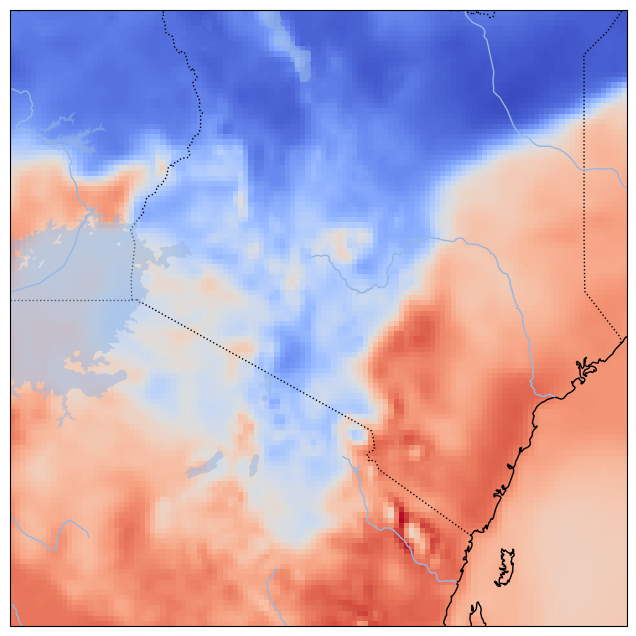

In [ ]:
# PLOTTING 

import matplotlib.pyplot as plt 
import cartopy.crs as ccr
import cartopy.feature as cfeature

plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccr.PlateCarree())

#EXTRACT 2D ARRAYS
lat = ds["XLAT"]
lon = ds["XLONG"]
data = rh.isel(time=0, bottom_top=0)

# PLOTTING WITH MESH 
mesh = ax.pcolormesh(lon, lat, data, cmap="coolwarm", transform=ccr.PlateCarree())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.add_feature(cfeature.RIVERS)
# ax.add_features(cfeature.STATES)
plt.colorbar(mesh, ax=ax, orientation='vertical', label='Relative Humidity (%)')
plt.title("Relative Humidity at 2m (First Time Step)") 
plt.show()

/home/erickwambugu/python-Projects/python_for_meteorology/WRF_OUTPUT_VISUALIZATION/venv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


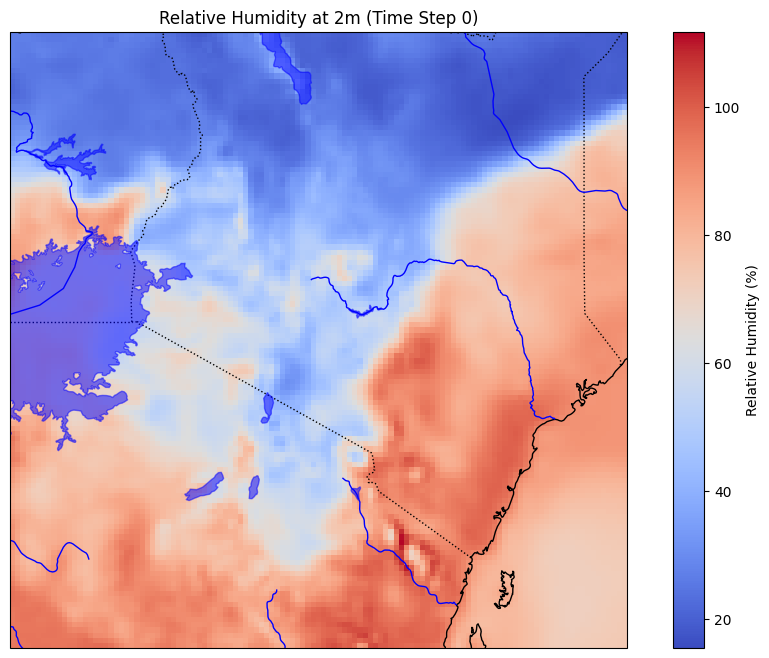

/home/erickwambugu/python-Projects/python_for_meteorology/WRF_OUTPUT_VISUALIZATION/venv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


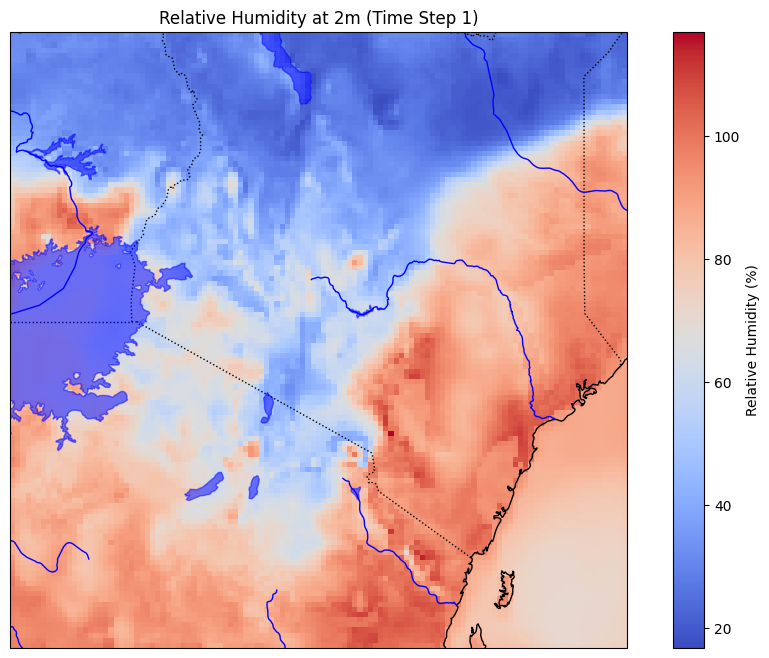

/home/erickwambugu/python-Projects/python_for_meteorology/WRF_OUTPUT_VISUALIZATION/venv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


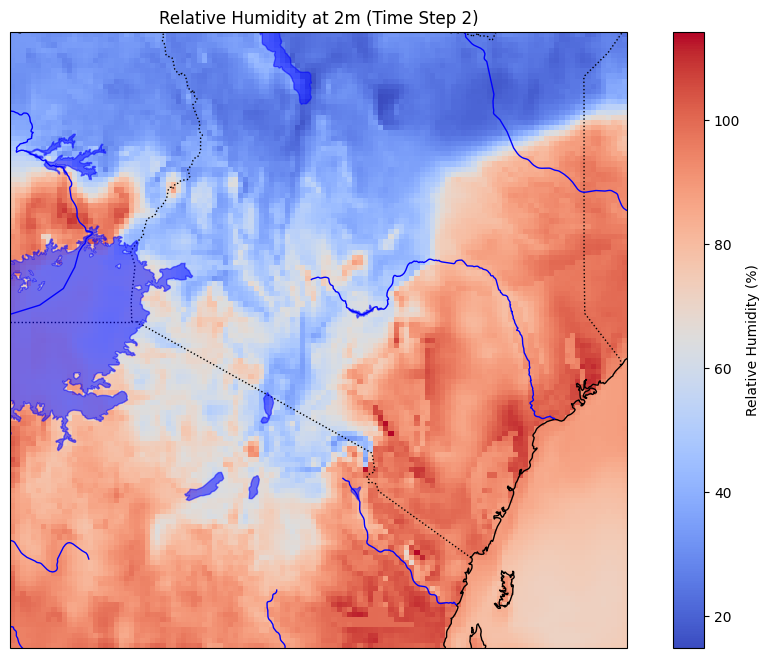

/home/erickwambugu/python-Projects/python_for_meteorology/WRF_OUTPUT_VISUALIZATION/venv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


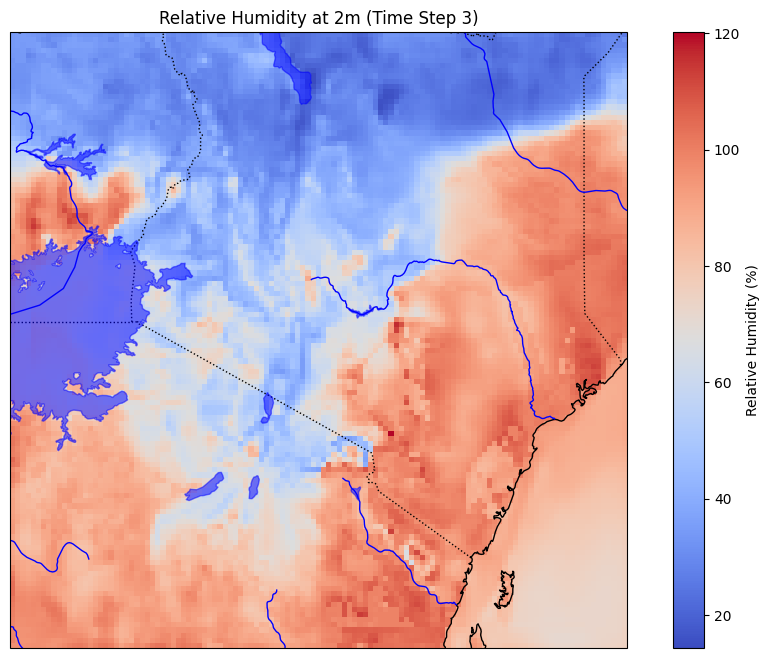

/home/erickwambugu/python-Projects/python_for_meteorology/WRF_OUTPUT_VISUALIZATION/venv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


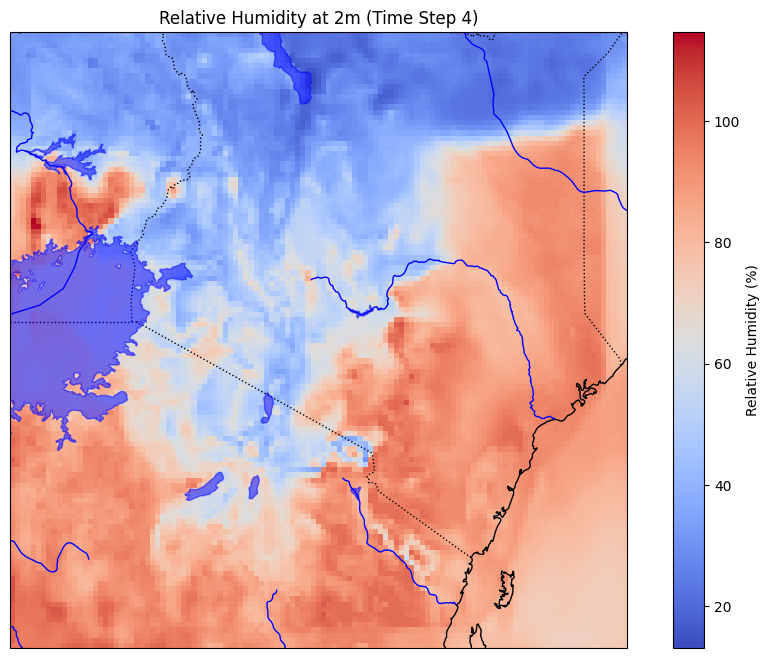

/home/erickwambugu/python-Projects/python_for_meteorology/WRF_OUTPUT_VISUALIZATION/venv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


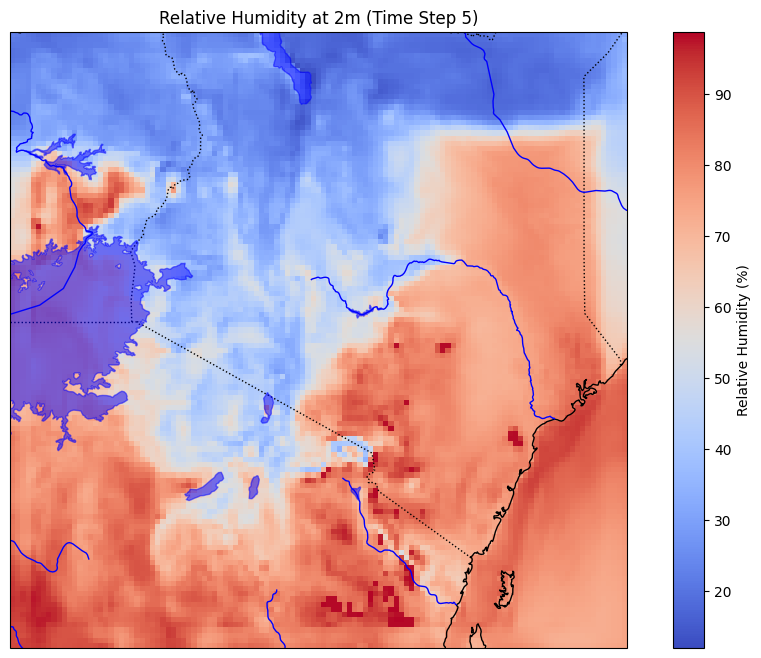

/home/erickwambugu/python-Projects/python_for_meteorology/WRF_OUTPUT_VISUALIZATION/venv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


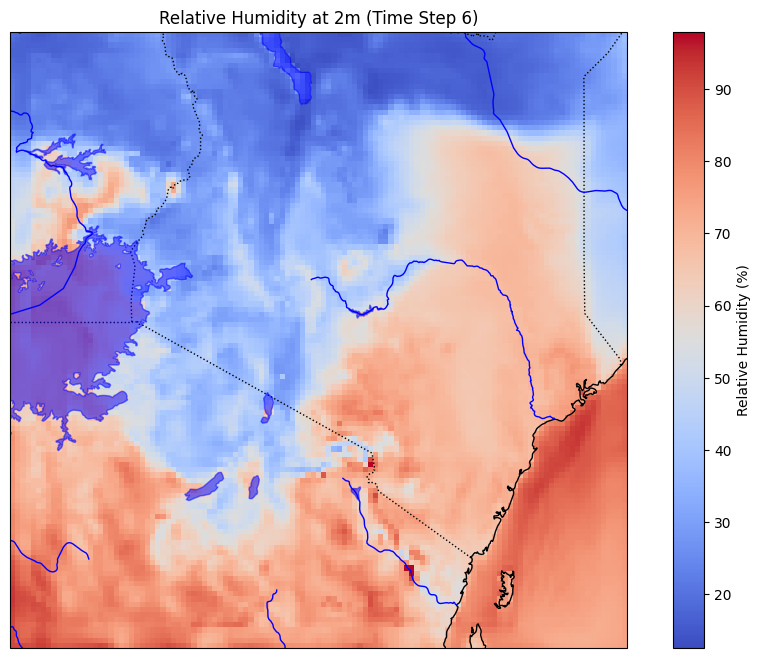

/home/erickwambugu/python-Projects/python_for_meteorology/WRF_OUTPUT_VISUALIZATION/venv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


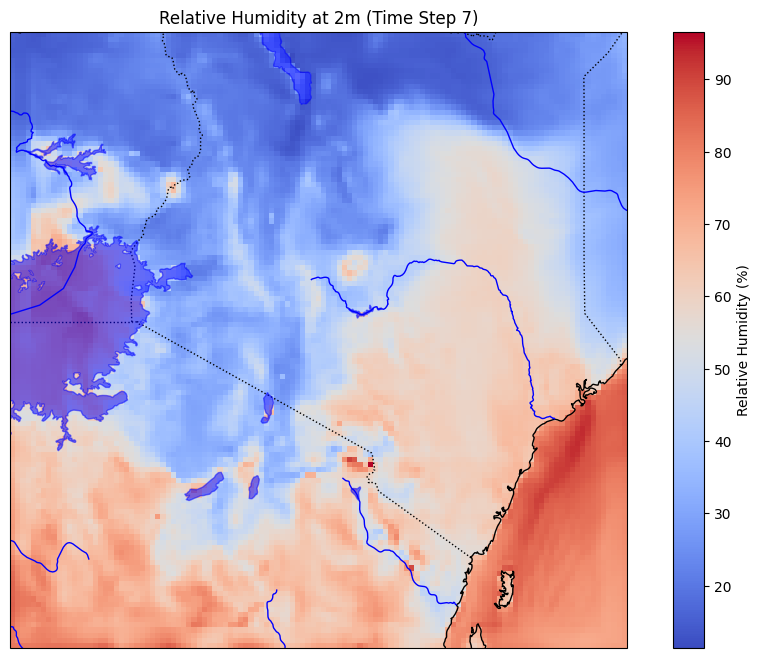

/home/erickwambugu/python-Projects/python_for_meteorology/WRF_OUTPUT_VISUALIZATION/venv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


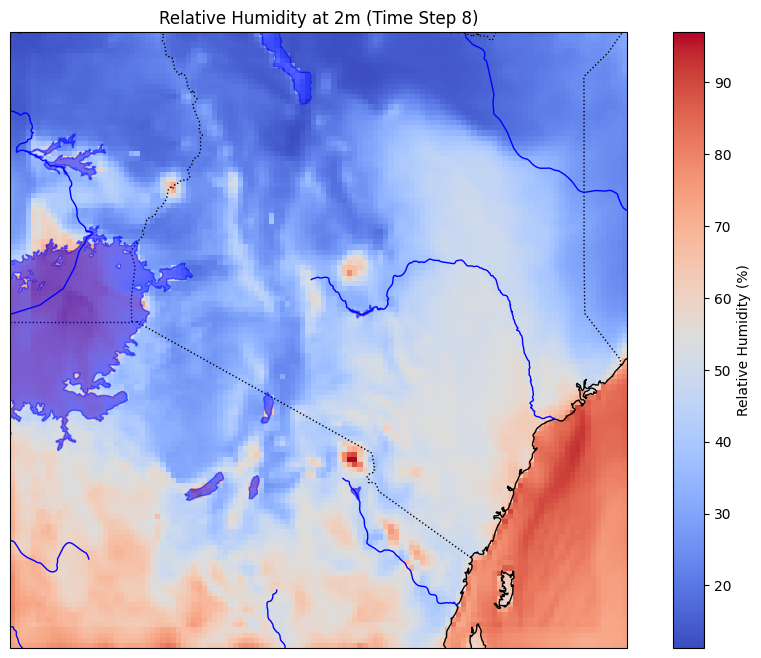

/home/erickwambugu/python-Projects/python_for_meteorology/WRF_OUTPUT_VISUALIZATION/venv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


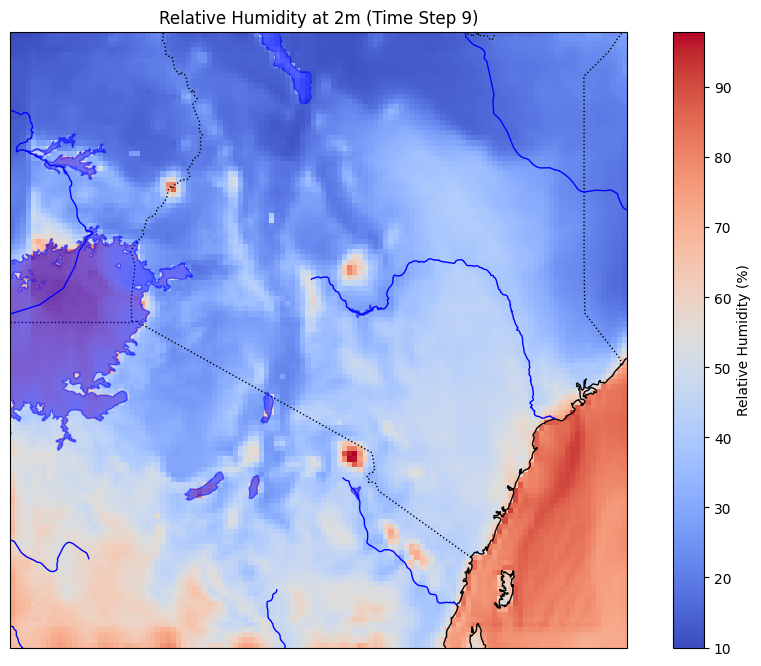

/home/erickwambugu/python-Projects/python_for_meteorology/WRF_OUTPUT_VISUALIZATION/venv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


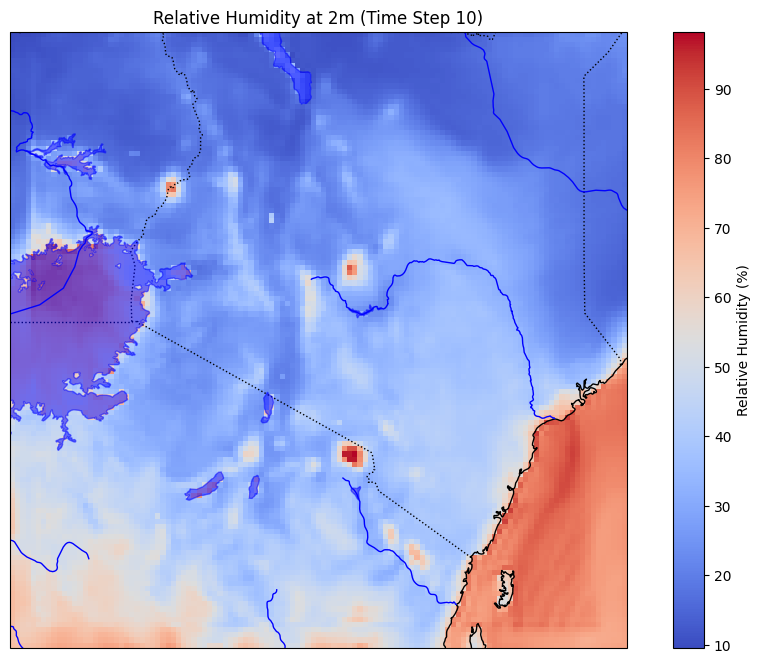

/home/erickwambugu/python-Projects/python_for_meteorology/WRF_OUTPUT_VISUALIZATION/venv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


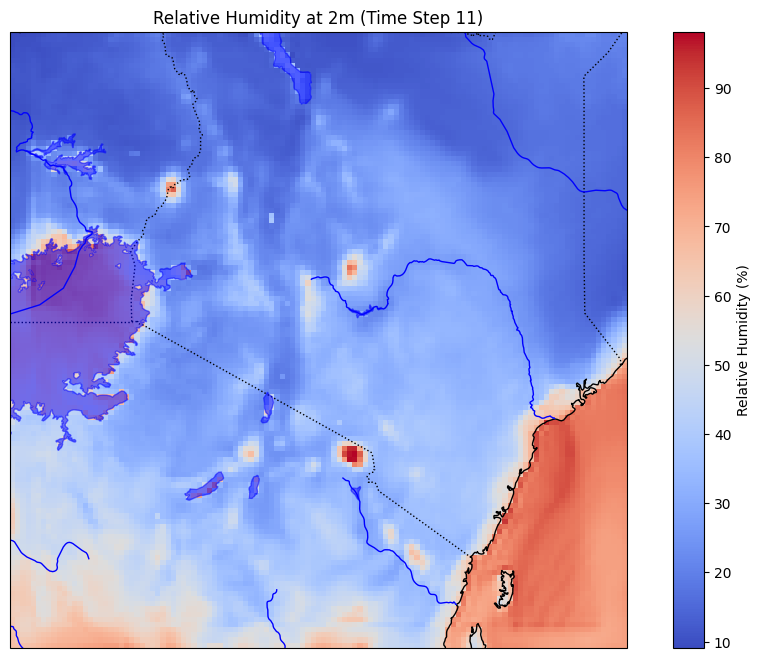

/home/erickwambugu/python-Projects/python_for_meteorology/WRF_OUTPUT_VISUALIZATION/venv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


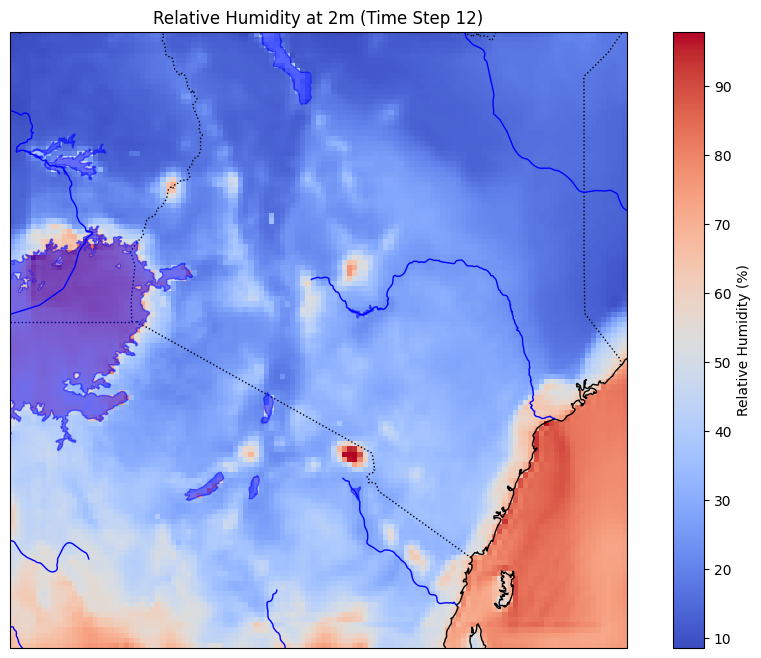

/home/erickwambugu/python-Projects/python_for_meteorology/WRF_OUTPUT_VISUALIZATION/venv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


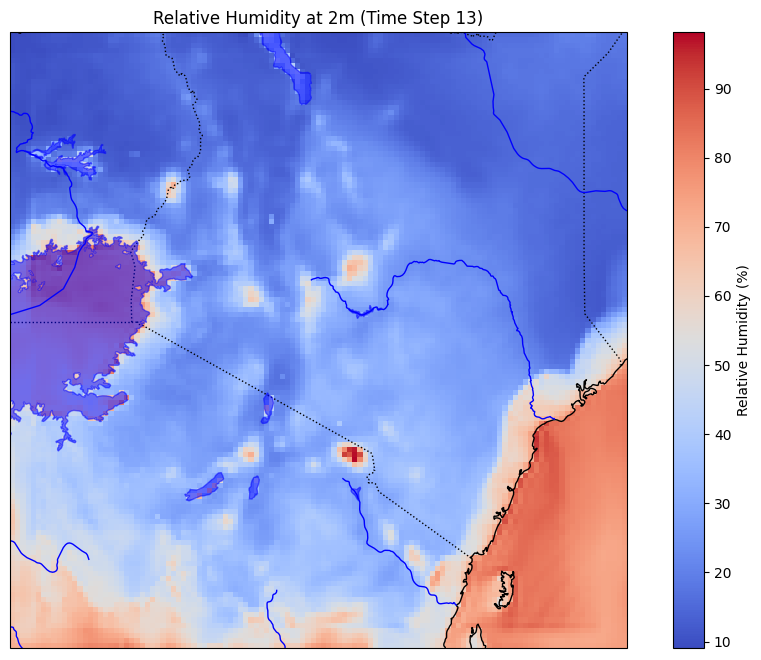

/home/erickwambugu/python-Projects/python_for_meteorology/WRF_OUTPUT_VISUALIZATION/venv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


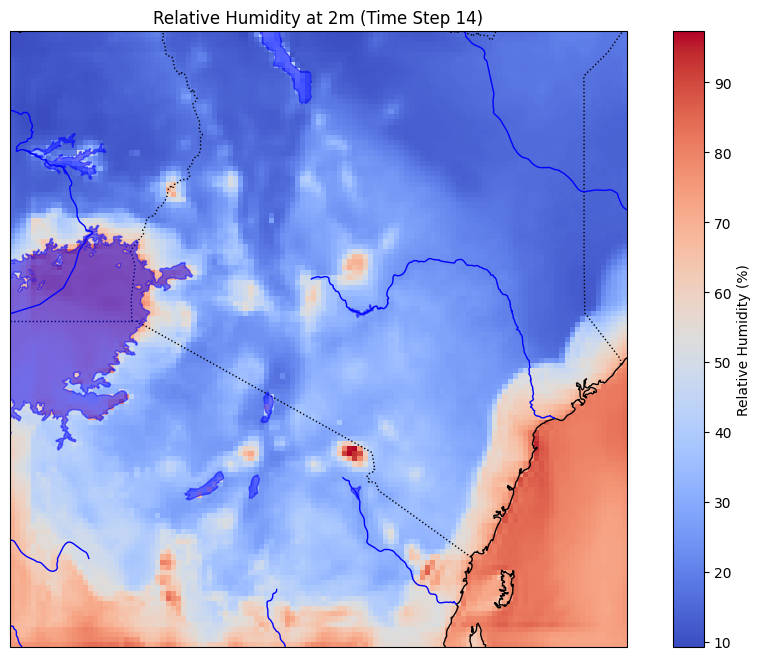

/home/erickwambugu/python-Projects/python_for_meteorology/WRF_OUTPUT_VISUALIZATION/venv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


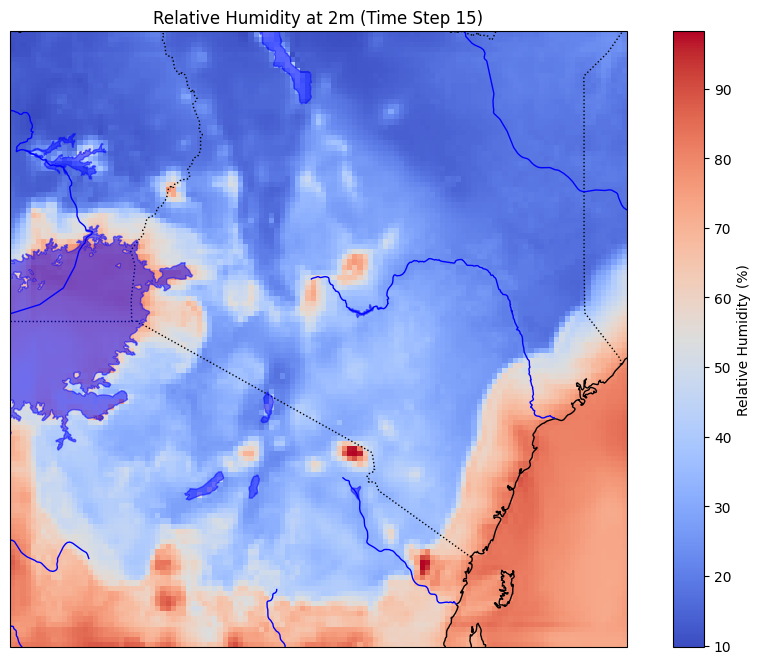

/home/erickwambugu/python-Projects/python_for_meteorology/WRF_OUTPUT_VISUALIZATION/venv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


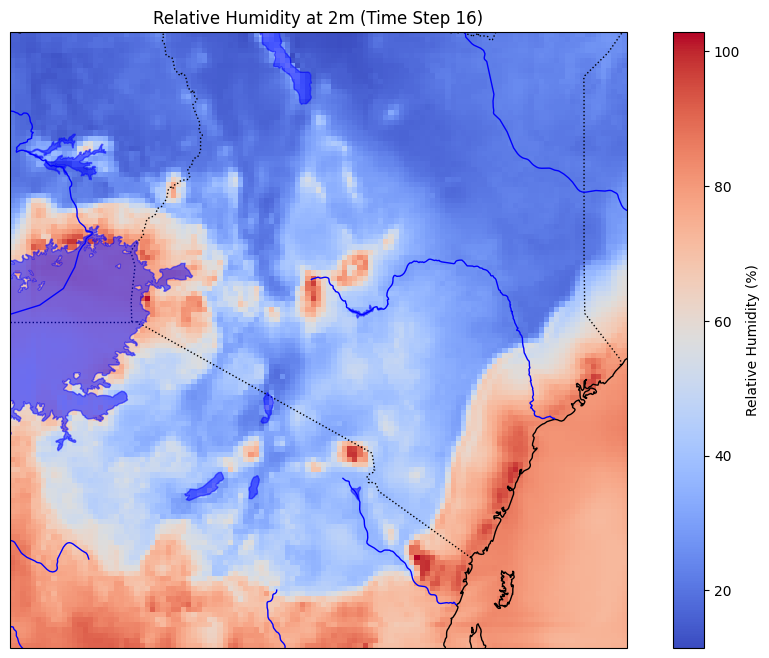

/home/erickwambugu/python-Projects/python_for_meteorology/WRF_OUTPUT_VISUALIZATION/venv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


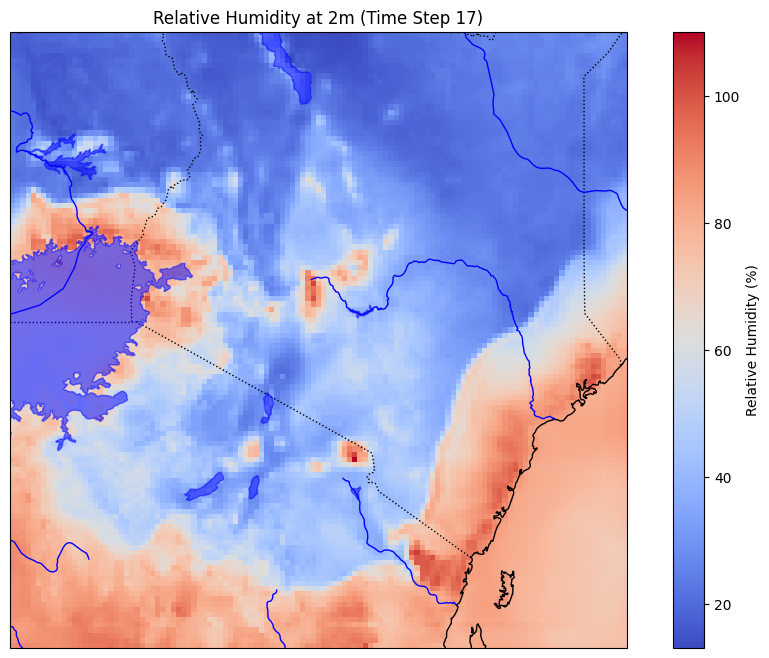

/home/erickwambugu/python-Projects/python_for_meteorology/WRF_OUTPUT_VISUALIZATION/venv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


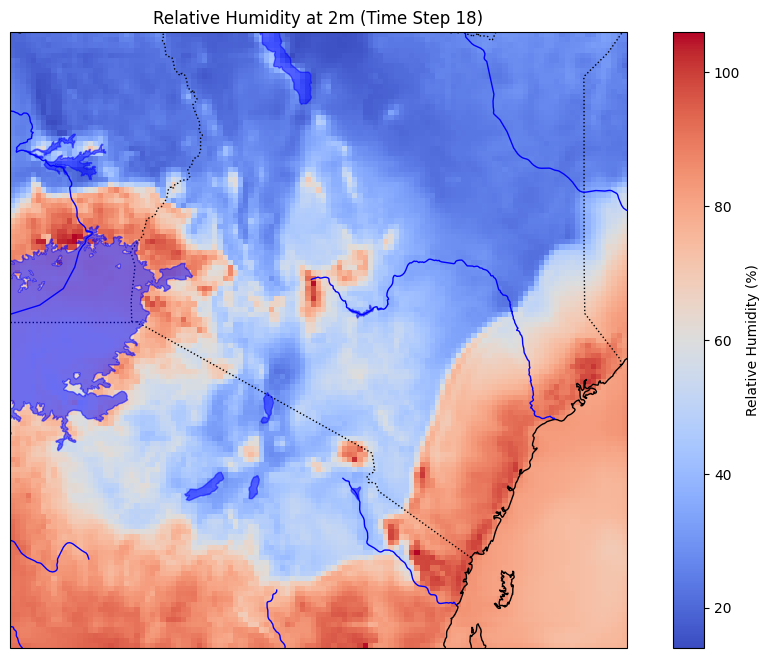

/home/erickwambugu/python-Projects/python_for_meteorology/WRF_OUTPUT_VISUALIZATION/venv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


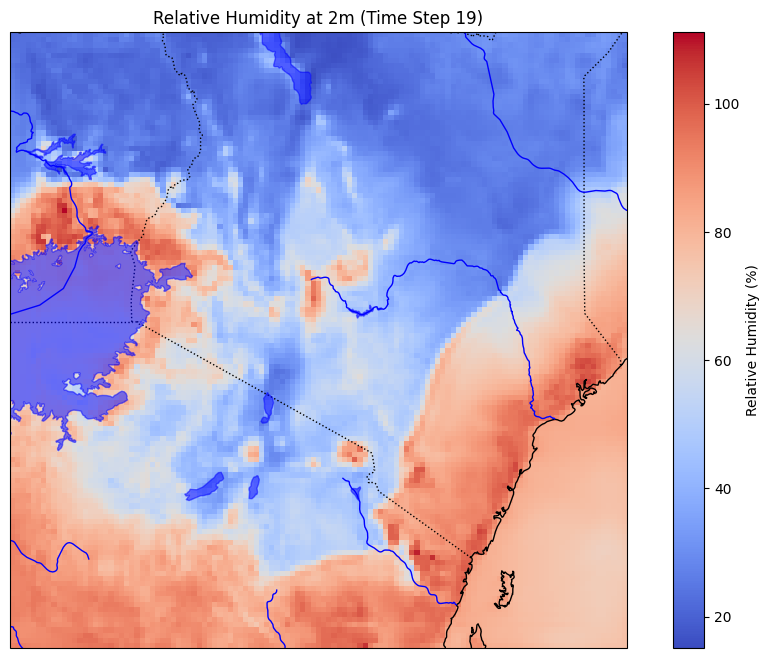

/home/erickwambugu/python-Projects/python_for_meteorology/WRF_OUTPUT_VISUALIZATION/venv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


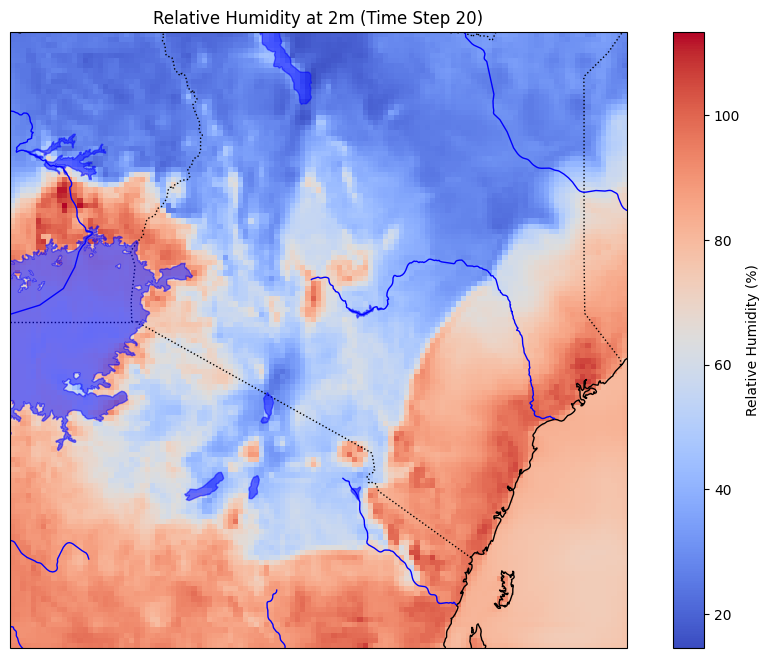

/home/erickwambugu/python-Projects/python_for_meteorology/WRF_OUTPUT_VISUALIZATION/venv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


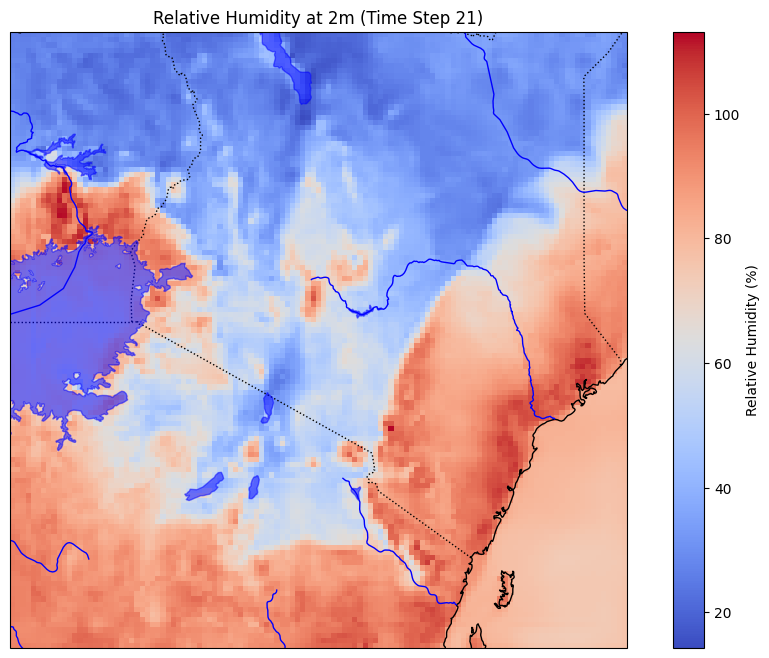

In [15]:
for i in range(len(ds.time)):
    plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccr.PlateCarree())

    #EXTRACT 2D ARRAYS
    lat = ds["XLAT"]
    lon = ds["XLONG"]
    data = rh.isel(time=i, bottom_top=0)

    # PLOTTING WITH MESH 
    mesh = ax.pcolormesh(lon, lat, data, cmap="coolwarm", transform=ccr.PlateCarree())

    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAKES, alpha=0.5, color="blue")
    ax.add_feature(cfeature.RIVERS, color="blue")
    plt.colorbar(mesh, ax=ax, orientation='vertical', label='Relative Humidity (%)')
    plt.title(f"Relative Humidity at 2m (Time Step {i})") 
    plt.show()